# Problem 1

This notebook provides code to:
- Plot the feasible set $S = \{(y_1,y_2): y_1^2 + \tfrac{1}{3}y_2^2 \le 1,\ y_1 \ge \tfrac{1}{2}\}$
- Verify that the given piecewise $f(x_1,x_2)$ equals the value function $\max_{(y_1,y_2)\in S} x_1y_1 + x_2y_2$
- Visualize the optimizer $y^*(x)$


(Utilities are in the next **code** cell.)

In [32]:
import numpy as np
import matplotlib.pyplot as plt


def f_piecewise(x1, x2):
    """Piecewise f(x1,x2) given in the prompt."""
    x1 = np.asarray(x1)
    x2 = np.asarray(x2)
    return np.where(
        np.abs(x2) <= x1,
        np.sqrt(x1**2 + 3 * x2**2),
        (x1 + 3 * np.abs(x2)) / 2,
    )


def y_star(x1, x2, eps=1e-12):
    """Argmax y*(x) for: max x1*y1 + x2*y2 over S.

    S = { (y1,y2): y1^2 + (1/3) y2^2 <= 1,  y1 >= 1/2 }.
    Returns (y1*, y2*).
    """
    x1 = float(x1)
    x2 = float(x2)

    denom = np.sqrt(x1**2 + 3 * x2**2)
    if denom < eps:
        return 0.5, 0.0

    # Unconstrained (ellipse-only) maximizer
    y1_unc = x1 / denom
    y2_unc = 3 * x2 / denom

    if y1_unc >= 0.5:
        return y1_unc, y2_unc

    # Constraint binds: y1=1/2, |y2|<=3/2
    return 0.5, (1.5 * np.sign(x2) if x2 != 0 else 0.0)


def f_value_from_max(x1, x2):
    """Value function computed from y*(x)."""
    y1, y2 = y_star(x1, x2)
    return x1 * y1 + x2 * y2


def plot_S(n=600):
    """Plot feasible region S in (y1,y2)."""
    y1 = np.linspace(-1, 1, n)
    y2 = np.sqrt(np.maximum(0.0, 3 * (1 - y1**2)))

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(y1, y2, color="black", lw=2)
    ax.plot(y1, -y2, color="black", lw=2, label=r"$y_1^2+\frac{1}{3}y_2^2=1$")

    y1_fill = np.linspace(0.5, 1.0, n)
    y2_fill = np.sqrt(np.maximum(0.0, 3 * (1 - y1_fill**2)))
    ax.fill_between(y1_fill, -y2_fill, y2_fill, alpha=0.25, label=r"Feasible $S$")

    ax.axvline(0.5, color="tab:red", ls="--", lw=2, label=r"$y_1=\frac{1}{2}$")
    ax.set_xlabel(r"$y_1$")
    ax.set_ylabel(r"$y_2$")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(True, alpha=0.25)
    ax.legend()
    ax.set_title("Feasible set S")
    plt.show()


def verify_on_grid(x1_range=(-2, 2), x2_range=(-2, 2), m=201):
    """Numerically verify f_piecewise == value function on a grid."""
    x1s = np.linspace(*x1_range, m)
    x2s = np.linspace(*x2_range, m)

    max_abs_err = 0.0
    worst = None
    for x1 in x1s:
        for x2 in x2s:
            fp = float(f_piecewise(x1, x2))
            fv = float(f_value_from_max(x1, x2))
            err = abs(fp - fv)
            if err > max_abs_err:
                max_abs_err = err
                worst = (x1, x2, fp, fv)

    return max_abs_err, worst


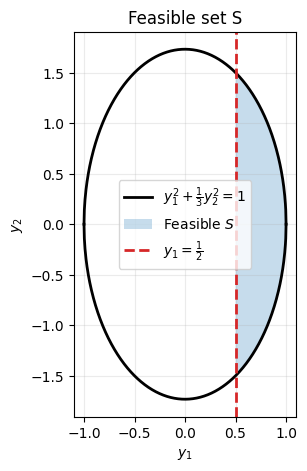

In [33]:
# (a) Plot S
plot_S()


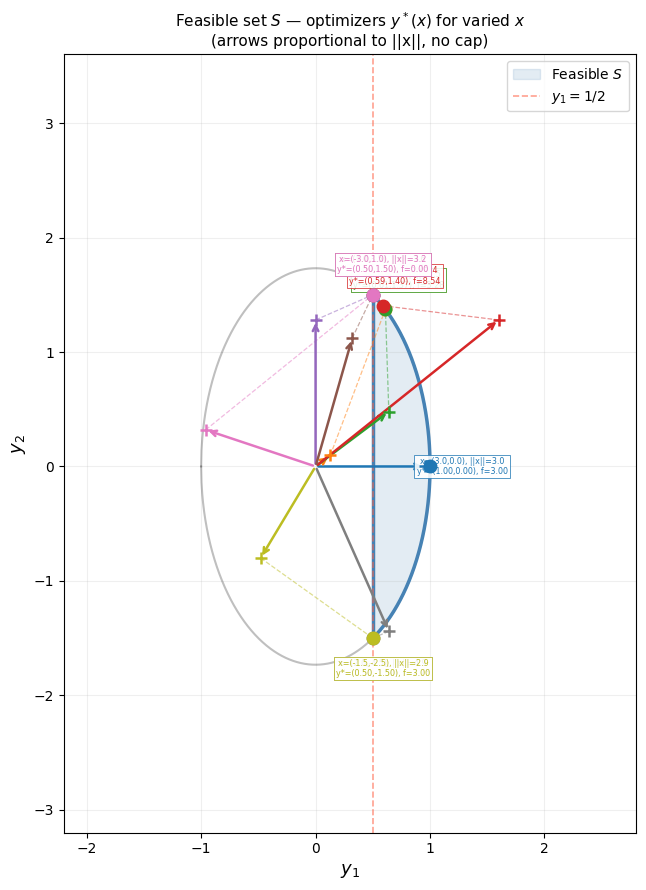

In [34]:

# (a) Plot S with varied x vectors — different directions, norms, both regimes

sample_xs = [
    # Arc regime (|x2| <= x1, x1 > 0)
    ( 3.0,  0.0),    # large norm, points right
    ( 0.4,  0.3),    # small norm (~0.5), shallow angle
    ( 2.0,  1.5),    # moderate norm, near arc/corner boundary
    ( 5.0,  4.0),    # very large norm, diagonal but still arc regime
    # Corner-pinned regime
    ( 0.0,  4.0),    # large norm, straight up → upper corner
    ( 1.0,  3.5),    # large norm, steep → upper corner
    (-3.0,  1.0),    # large norm, pointing left → upper corner
    ( 2.0, -4.5),    # very large norm, past lower corner
    (-1.5, -2.5),    # moderate-large norm, left+down → lower corner
]

colors = plt.cm.tab10.colors

n = 600
y1_arc = np.linspace(0.5, 1.0, n)
y2_arc = np.sqrt(np.maximum(0.0, 3 * (1 - y1_arc**2)))

fig, ax = plt.subplots(figsize=(10, 9))

# Full ellipse outline (faint)
y1_ell = np.linspace(-1, 1, n)
y2_ell = np.sqrt(np.maximum(0.0, 3 * (1 - y1_ell**2)))
ax.plot(y1_ell,  y2_ell, color="black", lw=1.5, alpha=0.25)
ax.plot(y1_ell, -y2_ell, color="black", lw=1.5, alpha=0.25)

# Shade feasible S
ax.fill_between(y1_arc, -y2_arc, y2_arc, alpha=0.15, color="steelblue", label="Feasible $S$")
ax.plot(y1_arc,  y2_arc, color="steelblue", lw=2.5)
ax.plot(y1_arc, -y2_arc, color="steelblue", lw=2.5)
ax.plot([0.5, 0.5], [-y2_arc[0], y2_arc[0]], color="steelblue", lw=2.5)

ax.axvline(0.5, color="tomato", ls="--", lw=1.2, alpha=0.6, label=r"$y_1 = 1/2$")
ax.set_aspect("equal")
ax.grid(True, alpha=0.2)
ax.set_xlabel(r"$y_1$", fontsize=13)
ax.set_ylabel(r"$y_2$", fontsize=13)
ax.set_title("Feasible set $S$ — optimizers $y^*(x)$ for varied $x$\n(arrows proportional to ||x||, no cap)", fontsize=11)

arrow_scale = 0.32   # plot units per unit of ||x|| — no cap applied

for i, (x1, x2) in enumerate(sample_xs):
    c = colors[i % len(colors)]
    y1s, y2s = y_star(x1, x2)
    val = x1 * y1s + x2 * y2s

    norm = np.sqrt(x1**2 + x2**2)
    tip_len = norm * arrow_scale          # proportional, uncapped
    tip = (tip_len * x1/norm, tip_len * x2/norm)

    # Arrow proportional to ||x||
    ax.annotate("", xy=tip, xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.8))

    # Cross at tip of x
    ax.plot(*tip, "+", color=c, ms=8, mew=1.8, zorder=6)

    # Dot at y*
    ax.plot(y1s, y2s, "o", color=c, ms=9, zorder=5)

    # Dashed connector from arrow tip to y*
    ax.plot([tip[0], y1s], [tip[1], y2s], "--", color=c, lw=0.9, alpha=0.5)

    # Label near y*
    offset_dir = np.array([y1s, y2s])
    offset_dir = offset_dir / (np.linalg.norm(offset_dir) + 1e-9) * 0.28
    label = f"x=({x1},{x2}), ||x||={norm:.1f}\ny*=({y1s:.2f},{y2s:.2f}), f={val:.2f}"
    ax.text(y1s + offset_dir[0], y2s + offset_dir[1], label,
            fontsize=5.8, color=c, ha="center", va="center",
            bbox=dict(fc="white", ec=c, lw=0.6, alpha=0.88, pad=1.5))

ax.set_xlim(-2.2, 2.8)
ax.set_ylim(-3.2, 3.6)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


### Part (a) — Intuition from the plot

The feasible set $S$ is the portion of the filled ellipse $y_1^2 + \tfrac{1}{3}y_2^2 \le 1$ that lies to the right of the vertical line $y_1 = \tfrac{1}{2}$. Its boundary consists of a **curved arc** (the right part of the ellipse) joined at two **corner points** $\bigl(\tfrac{1}{2},\, \tfrac{3}{2}\bigr)$ and $\bigl(\tfrac{1}{2},\, -\tfrac{3}{2}\bigr)$ by a **flat vertical edge**.

The objective $x_1 y_1 + x_2 y_2$ is the dot product of the fixed parameter vector $x = (x_1, x_2)$ with the decision variable $y$. Maximizing it over $S$ means finding the point on the boundary of $S$ that lies furthest in the direction of $x$ — the **support point** of $S$ along $x$.

From the plot, two regimes are visible:

**Regime 1 — $x$ points toward the arc** (e.g. $x = (1,0)$, $(2.5, 0)$, $(1, \pm 0.8)$).  
When the direction of $x$ is "covered" by the ellipse arc of $S$, the optimizer $y^*(x)$ slides along the arc to the support point of the ellipse in that direction. Crucially, **only the direction of $x$ matters**: the vectors $(0.25, 0)$ and $(2.5, 0)$ yield the exact same $y^* = (1, 0)$ even though their norms differ by a factor of 10. The norm of $x$ only scales the optimal value $f$.

**Regime 2 — $x$ points past a corner** (e.g. $x = (0.5, 1.5)$, $(1.8, 1.8)$, $(0.4, -2.0)$, $(-1, 0.5)$).  
When the direction of $x$ is "outside" the cone subtended by the arc, the support point of the unconstrained ellipse would violate $y_1 \ge \tfrac{1}{2}$. The optimizer is then **pinned to the nearer corner**: $\bigl(\tfrac{1}{2}, \tfrac{3}{2}\bigr)$ when $x_2 > 0$, and $\bigl(\tfrac{1}{2}, -\tfrac{3}{2}\bigr)$ when $x_2 < 0$. All such vectors share the same $y^*$ regardless of norm or how far past the corner they point.

The **transition** between regimes occurs when the direction of $x$ points exactly toward one of the two corners — this is the critical direction separating the two cases, which we make precise in parts (b)–(d).


### Part (b) — Unique optimal solution of (P)

**(P)** $\max_{(y_1,y_2)} \ x_1 y_1 + x_2 y_2 \quad \text{s.t.} \quad y_1^2 + \tfrac{1}{3}y_2^2 \le 1.$

We assume $(x_1, x_2) \neq (0,0)$ throughout (otherwise every point on the ellipse achieves value 0 and uniqueness fails trivially).

---

**Existence.** The feasible set $\mathcal{E} = \{(y_1,y_2): y_1^2 + \tfrac{1}{3}y_2^2 \le 1\}$ is compact and non-empty. The objective is continuous. By the Weierstrass extreme value theorem, the maximum is attained.

---

**Optimizers lie on the boundary.** For any interior point $y$ (i.e. $y_1^2 + \tfrac{1}{3}y_2^2 < 1$), consider scaling: $ty$ for $t > 1$ chosen so that $ty$ lies on the ellipse boundary. Since the objective is linear,
$$x_1(ty_1) + x_2(ty_2) = t\,(x_1 y_1 + x_2 y_2) > x_1 y_1 + x_2 y_2$$
provided $x_1 y_1 + x_2 y_2 > 0$. (For $x \neq 0$ the maximum value is always positive, so any interior point cannot be optimal.) Hence every optimal solution lies on the boundary $y_1^2 + \tfrac{1}{3}y_2^2 = 1$.

---

**Uniqueness (proof by contradiction).** Suppose $\tilde{y}^{(1)} \neq \tilde{y}^{(2)}$ are two distinct optimal solutions, both achieving value $v^*$. Both lie on the ellipse boundary as shown above.

Consider the midpoint $\bar{y} = \tfrac{1}{2}(\tilde{y}^{(1)} + \tilde{y}^{(2)})$.

- *Feasibility:* $\mathcal{E}$ is convex, so $\bar{y} \in \mathcal{E}$.
- *Achieves $v^*$:* By linearity, $x_1\bar{y}_1 + x_2\bar{y}_2 = \tfrac{1}{2}(v^* + v^*) = v^*$.
- *Lies in the interior:* Since $\tilde{y}^{(1)} \neq \tilde{y}^{(2)}$ both lie on the strictly convex ellipse boundary, their midpoint lies strictly inside: $\bar{y}_1^2 + \tfrac{1}{3}\bar{y}_2^2 < 1$.

Now scale $\bar{y}$ outward to the boundary: let $\hat{y} = t\bar{y}$ with $t > 1$ such that $\hat{y}_1^2 + \tfrac{1}{3}\hat{y}_2^2 = 1$. Using the dot product's geometric form,
$$x \cdot \hat{y} = \|x\|\,\|\hat{y}\|\cos\theta = t\,\|x\|\,\|\bar{y}\|\cos\theta = t\,(x\cdot\bar{y}) = tv^* > v^*,$$
where $\theta$ is the angle between $x$ and $\bar{y}$ (unchanged by scaling). This contradicts $v^*$ being the maximum.

Therefore no two distinct optimal solutions exist. Combined with existence, **(P) has exactly one optimal solution $(\tilde{y}_1, \tilde{y}_2)$**.

---

**Explicit expression.** Since the optimizer lies on the boundary, we write the Lagrangian:
$$\mathcal{L}(y_1, y_2, \lambda) = x_1 y_1 + x_2 y_2 - \lambda\!\left(y_1^2 + \tfrac{1}{3}y_2^2 - 1\right).$$

Setting partial derivatives to zero:
$$\frac{\partial \mathcal{L}}{\partial y_1} = x_1 - 2\lambda y_1 = 0 \implies \tilde{y}_1 = \frac{x_1}{2\lambda},$$
$$\frac{\partial \mathcal{L}}{\partial y_2} = x_2 - \frac{2\lambda}{3} y_2 = 0 \implies \tilde{y}_2 = \frac{3x_2}{2\lambda},$$
$$\frac{\partial \mathcal{L}}{\partial \lambda} = -\!\left(\tilde{y}_1^2 + \tfrac{1}{3}\tilde{y}_2^2 - 1\right) = 0 \implies \tilde{y}_1^2 + \tfrac{1}{3}\tilde{y}_2^2 = 1.$$

Substituting the first two into the third:
$$\frac{x_1^2}{4\lambda^2} + \frac{1}{3}\cdot\frac{9x_2^2}{4\lambda^2} = 1 \implies \frac{x_1^2 + 3x_2^2}{4\lambda^2} = 1 \implies \lambda = \pm\frac{\sqrt{x_1^2 + 3x_2^2}}{2}.$$

Taking $\lambda > 0$: at this critical point $\nabla f = \lambda \nabla g$ with $\lambda > 0$, meaning $\nabla f$ points in the same direction as the outward normal to the ellipse — i.e. the objective is trying to push outward, so we are at a maximum (not a minimum). One can verify directly: the objective value is $\sqrt{x_1^2+3x_2^2} > 0$ for $\lambda>0$ and $-\sqrt{x_1^2+3x_2^2}<0$ for $\lambda<0$.

$$\boxed{\tilde{y}_1 = \frac{x_1}{\sqrt{x_1^2 + 3x_2^2}}, \qquad \tilde{y}_2 = \frac{3x_2}{\sqrt{x_1^2 + 3x_2^2}}.}$$


The corresponding maximum value is obtained by substituting back into the objective:
$$v^* = x_1\tilde{y}_1 + x_2\tilde{y}_2 = \frac{x_1^2}{\sqrt{x_1^2+3x_2^2}} + \frac{3x_2^2}{\sqrt{x_1^2+3x_2^2}} = \frac{x_1^2+3x_2^2}{\sqrt{x_1^2+3x_2^2}} = \boxed{\sqrt{x_1^2+3x_2^2}.}$$

### Part (c) — When $\tilde{y}_1 \ge \tfrac{1}{2}$

The condition $\tilde{y}_1 \ge \tfrac{1}{2}$ means:
$$\frac{x_1}{\sqrt{x_1^2 + 3x_2^2}} \ge \frac{1}{2}.$$

This requires $x_1 > 0$. Squaring both sides (both are non-negative):
$$4x_1^2 \ge x_1^2 + 3x_2^2 \implies 3x_1^2 \ge 3x_2^2 \implies x_1^2 \ge x_2^2 \implies \sqrt{x_1^2} \ge \sqrt{x_2^2} \implies |x_1| \ge |x_2| \land (x_1>0) \implies x_1 \ge |x_2| \implies |x_2| \le x_1.$$

So the condition is $\boxed{|x_2| \le x_1}$.

In this case the halfspace constraint $y_1 \ge \tfrac{1}{2}$ is automatically satisfied by the unconstrained ellipse optimizer from part (b), so the optimal solution of (2) is unchanged:
$$y_1^* = \frac{x_1}{\sqrt{x_1^2 + 3x_2^2}}, \qquad y_2^* = \frac{3x_2}{\sqrt{x_1^2 + 3x_2^2}},$$
with optimal value $v^* = \sqrt{x_1^2 + 3x_2^2}$.

---

### Part (d) — When $\tilde{y}_1 < \tfrac{1}{2}$

This occurs when $|x_2| > x_1$ (including all $x_1 \le 0$). The halfspace constraint is now binding, so the $y_1$ component of the optimal solution is:
$$y_1^* = \frac{1}{2}.$$

With $y_1 = \tfrac{1}{2}$ fixed, the ellipse constraint gives $|y_2| \le \tfrac{3}{2}$, and the objective reduces to maximizing $x_2 y_2$ over $y_2 \in [-\tfrac{3}{2}, \tfrac{3}{2}]$. Therefore:

$$y_2^* = \begin{cases} \tfrac{3}{2} & \text{if } x_2 > 0, \\ -\tfrac{3}{2} & \text{if } x_2 < 0, \\ \text{any } y_2 \in \bigl[-\tfrac{3}{2},\, \tfrac{3}{2}\bigr] & \text{if } x_2 = 0. \end{cases}$$

When $x_2 = 0$ (and $x_1 \le 0$), the objective is $x_1 \cdot \tfrac{1}{2} + 0 \cdot y_2 = \tfrac{x_1}{2}$ regardless of $y_2$, so the optimizer is not unique — every point on the flat edge $\{y_1 = \tfrac{1}{2},\ |y_2| \le \tfrac{3}{2}\}$ is optimal.

For $x_2 \neq 0$, the optimal value is:
$$v^* = \frac{x_1}{2} + x_2 \cdot \frac{3}{2}\operatorname{sign}(x_2) = \frac{x_1 + 3|x_2|}{2}.$$

**Conclusion.** Combining parts (c) and (d), the value function of (2) is:
$$f(x_1, x_2) = \begin{cases} \sqrt{x_1^2 + 3x_2^2} & \text{if } |x_2| \le x_1, \\ \dfrac{x_1 + 3|x_2|}{2} & \text{otherwise,} \end{cases}$$
which is exactly the piecewise formula (1). $\blacksquare$


### Part (e) — $f$ is convex

From parts (c) and (d) we have established that
$$f(x_1, x_2) = \max_{(y_1, y_2) \in S}\ x_1 y_1 + x_2 y_2.$$

For each **fixed** $(y_1, y_2) \in S$, the map
$$\phi_{y}(x_1, x_2) := x_1 y_1 + x_2 y_2$$
is **linear** in $(x_1, x_2)$, hence convex.

Since $f$ is the pointwise supremum of a family of convex functions,
$$f(x_1, x_2) = \sup_{(y_1,y_2)\in S}\ \phi_y(x_1, x_2),$$
it is convex. To see this directly: for any $(x^{(1)}, x^{(2)}) \in \mathbb{R}^2$ and $\lambda \in [0,1]$, let $x^\lambda = \lambda x^{(1)} + (1-\lambda)x^{(2)}$. For any $(y_1, y_2) \in S$,
$$\phi_y(x^\lambda) = \lambda\, \phi_y(x^{(1)}) + (1-\lambda)\,\phi_y(x^{(2)}) \le \lambda\, f(x^{(1)}) + (1-\lambda)\, f(x^{(2)}).$$
Taking the supremum over $(y_1, y_2) \in S$ on the left:
$$f(x^\lambda) \le \lambda\, f(x^{(1)}) + (1-\lambda)\, f(x^{(2)}). \qquad \blacksquare$$


In [35]:
# Quick verification: piecewise f(x) equals max_{y in S} x·y
max_abs_err, worst = verify_on_grid(m=161)
max_abs_err, worst


(1.3322676295501878e-15,
 (np.float64(1.7000000000000002),
  np.float64(-1.45),
  3.0327380368241506,
  3.032738036824149))

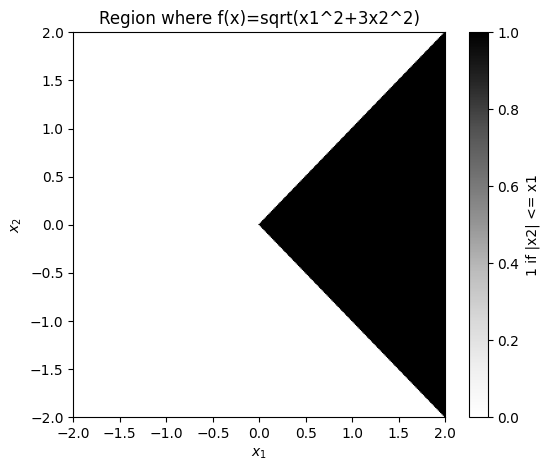

In [36]:
# Visualize which branch is active: |x2| <= x1 vs otherwise
m = 301
x1 = np.linspace(-2, 2, m)
x2 = np.linspace(-2, 2, m)
X1, X2 = np.meshgrid(x1, x2, indexing="xy")
mask = (np.abs(X2) <= X1)

plt.figure(figsize=(6, 5))
plt.imshow(mask.astype(float), origin="lower", extent=[x1.min(), x1.max(), x2.min(), x2.max()], aspect="auto", cmap="Greys")
plt.colorbar(label="1 if |x2| <= x1")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.title("Region where f(x)=sqrt(x1^2+3x2^2)")
plt.show()


## Problem 2

### Part (a) — Prove $\partial f(x) \subseteq A(x)$

Recall $f(x_1,x_2) = \max_{(y_1,y_2)\in S}\, x_1 y_1 + x_2 y_2$ and $A(x) = \operatorname{argmax}_{y\in S}\, x^\top y$.

Let $g \in \partial f(x)$. By definition of subgradient:
$$f(z) \ge f(x) + g^\top(z - x) \quad \forall\, z. \tag{$*$}$$

We show $g \in A(x)$ by proving two things: $g \in S$ and $x^\top g = f(x)$.

---

**Step 1 — $g \in S$.**

Since $f$ is a support function, it is **positively homogeneous**: for any $v$ and $t > 0$,
$$f(tv) = \sup_{y\in S}\, tv^\top y = t\sup_{y\in S}\, v^\top y = t\,f(v).$$

Substituting $z = tv$ into $(*)$:
$$t\,f(v) \ge f(x) + g^\top(tv - x) = f(x) - g^\top x + t\,(g^\top v).$$

Dividing by $t > 0$ and letting $t \to \infty$:
$$f(v) \ge g^\top v \quad \forall\, v.$$

Since $f(v) = \sup_{y\in S} v^\top y$, this says $\sup_{y\in S} v^\top y \ge v^\top g$ for all $v$. By the supporting hyperplane characterization of closed convex sets, this implies $g \in S$.

---

**Step 2 — $x^\top g = f(x)$.**

Since $g \in S$:
$$x^\top g \le \sup_{y\in S}\, x^\top y = f(x). \tag{i}$$

Substituting $z = 0$ into $(*)$ and using $f(0) = \sup_{y\in S} 0 = 0$:
$$0 \ge f(x) - g^\top x \implies x^\top g \ge f(x). \tag{ii}$$

Combining (i) and (ii): $x^\top g = f(x) = \sup_{y\in S}\, x^\top y$.

---

**Conclusion.** $g \in S$ and $x^\top g = \sup_{y\in S}\, x^\top y$, so $g \in \operatorname{argmax}_{y\in S}\, x^\top y = A(x)$. Therefore $\partial f(x) \subseteq A(x)$. $\blacksquare$


### Part (b) — Explicit expression of $\partial f(x_1, x_2)$

By part (a), $\partial f(x) = A(x) = \operatorname{argmax}_{y \in S}\, x^\top y$. We read off the argmax from parts (c) and (d) of Problem 1.

---

**Case 1: $x_1 = x_2 = 0$.**

The objective $x^\top y = 0$ for every $y \in S$, so every point in $S$ achieves the maximum:
$$\partial f(0,0) = S.$$

---

**Case 2: $|x_2| \le x_1$, $x_1 \ne 0$.**

From part (c), the halfspace constraint is inactive and the unique argmax is the unconstrained ellipse optimizer:
$$\partial f(x_1,x_2) = \left\{\left(\frac{x_1}{\sqrt{x_1^2+3x_2^2}},\ \frac{3x_2}{\sqrt{x_1^2+3x_2^2}}\right)\right\}.$$

This is a singleton — $f$ is differentiable here and the subdifferential is just the gradient.

---

**Case 3: $|x_2| > x_1$, $x_2 \ne 0$.**

From part (d), the halfspace constraint is binding and the unique argmax is the corner:
$$\partial f(x_1,x_2) = \left\{\left(\tfrac{1}{2},\ \tfrac{3}{2}\operatorname{sign}(x_2)\right)\right\}.$$

Again a singleton — $f$ is differentiable in this region.

---

**Case 4: $x_2 = 0$, $x_1 < 0$.**

The objective reduces to $x_1 y_1$. Since $x_1 < 0$, this is maximized by $y_1 = \tfrac{1}{2}$ (as small as possible). The $y_2$ component does not appear in the objective, so any $y_2 \in [-\tfrac{3}{2}, \tfrac{3}{2}]$ achieves the maximum:
$$\partial f(x_1, 0) = \left\{\left(\tfrac{1}{2},\ y_2\right) : y_2 \in \left[-\tfrac{3}{2},\ \tfrac{3}{2}\right]\right\}.$$

This is a line segment — $f$ is non-differentiable here and the subdifferential is not a singleton. $\blacksquare$


## Problem 3

### Part (a) — $f$ is differentiable at $(x_1^{(t)}, x_2^{(t)})$ satisfying $|x_2^{(t)}| \le x_1^{(t)}$, $x_1^{(t)} \ne 0$

From part 2(b) Case 2, when $|x_2| \le x_1$ and $x_1 \ne 0$, the subdifferential is a singleton:
$$\partial f(x_1, x_2) = \left\{\left(\frac{x_1}{\sqrt{x_1^2+3x_2^2}},\ \frac{3x_2}{\sqrt{x_1^2+3x_2^2}}\right)\right\}.$$

A convex function is differentiable at $x$ if and only if its subdifferential is a singleton. Therefore $f$ is differentiable at $(x_1^{(t)}, x_2^{(t)})$, with gradient:
$$\nabla f\!\left(x_1^{(t)}, x_2^{(t)}\right) = \left(\frac{x_1^{(t)}}{\sqrt{(x_1^{(t)})^2+3(x_2^{(t)})^2}},\ \frac{3x_2^{(t)}}{\sqrt{(x_1^{(t)})^2+3(x_2^{(t)})^2}}\right). \qquad \blacksquare$$


### Part (b) — Derivative of $g(h) = f\bigl(x^{(t)} - h\nabla f(x^{(t)})\bigr)$

Let $r = \sqrt{(x_1^{(t)})^2 + 3(x_2^{(t)})^2}$ and write $x = (x_1^{(t)}, x_2^{(t)})$ for brevity. From part (a):
$$\nabla f(x) = \left(\frac{x_1}{r},\ \frac{3x_2}{r}\right).$$

The iterate along the line search is:
$$z(h) = x - h\nabla f(x) = \left(x_1\!\left(1 - \frac{h}{r}\right),\ x_2\!\left(1 - \frac{3h}{r}\right)\right).$$

One can verify that $|z_2(h)| \le z_1(h)$ and $z_1(h) \ne 0$ for $h$ in a neighbourhood of $0$, so $f$ is differentiable at $z(h)$ and by the chain rule:
$$g'(h) = \nabla f(z(h))^\top \cdot (-\nabla f(x)).$$

Let $s = s(h) = \sqrt{z_1^2 + 3z_2^2}$. Since $z(h)$ is in the smooth region, $\nabla f(z(h)) = \bigl(z_1/s,\ 3z_2/s\bigr)$, so:
$$g'(h) = -\left(\frac{z_1}{s}\cdot\frac{x_1}{r} + \frac{3z_2}{s}\cdot\frac{3x_2}{r}\right) = -\frac{x_1 z_1 + 9x_2 z_2}{r\cdot s}.$$

Substituting $z_1 = x_1(1-h/r)$ and $z_2 = x_2(1-3h/r)$:

$$\boxed{g'(h) = -\frac{x_1^2\bigl(1-\tfrac{h}{r}\bigr) + 9x_2^2\bigl(1-\tfrac{3h}{r}\bigr)}{r\cdot\sqrt{x_1^2\bigl(1-\tfrac{h}{r}\bigr)^2 + 3x_2^2\bigl(1-\tfrac{3h}{r}\bigr)^2}}.}$$


### Part (c) — Exact line search step size for $x_1^{(t)} = 3(1/2)^t,\ x_2^{(t)} = (-1/2)^t$

First note that $|x_2^{(t)}| = (1/2)^t \le 3(1/2)^t = x_1^{(t)}$, so condition (4) holds and the formula from part (b) applies. With these values:
$$r = \sqrt{x_1^2 + 3x_2^2} = \sqrt{9 \cdot (1/2)^{2t} + 3 \cdot (1/2)^{2t}} = 2\sqrt{3}\,(1/2)^t.$$

Substituting $h = \sqrt{3}(1/2)^t$, $x_1 = 3(1/2)^t$, $x_2 = (-1/2)^t$, $r = 2\sqrt{3}(1/2)^t$ into $g'(h)$ from part (b), the numerator becomes:

$$x_1^2\!\left(1 - \frac{h}{r}\right) + 9x_2^2\!\left(1 - \frac{3h}{r}\right) = 9(1/2)^{2t}\!\left(1 - \frac{1}{2}\right) + 9(1/2)^{2t}\!\left(1 - \frac{3}{2}\right) = \frac{9}{2}(1/2)^{2t} - \frac{9}{2}(1/2)^{2t} = 0.$$

Hence $g'\!\left(\sqrt{3}(1/2)^t\right) = 0$. 

Since $f$ is convex (proved in Problem 1(e)) and $h \mapsto x^{(t)} - h\nabla f(x^{(t)})$ is affine in $h$, $g(h) = f(x^{(t)} - h\nabla f(x^{(t)}))$ is convex in $h$ as the composition of a convex function with an affine map. Therefore $g'(h^*) = 0$ is sufficient for a global minimum, and the exact line search produces $h_t = \sqrt{3}(1/2)^t$. $\blacksquare$


### Part (d) — Induction step: $x^{(t+1)} = \bigl(3(1/2)^{t+1},\ (-1/2)^{t+1}\bigr)$

Using $\nabla f(x^{(t)}) = \bigl(x_1/r,\ 3x_2/r\bigr)$ from part (a) with $r = 2\sqrt{3}(1/2)^t$:
$$\nabla f(x^{(t)}) = \left(\frac{3(1/2)^t}{2\sqrt{3}(1/2)^t},\ \frac{3(-1/2)^t}{2\sqrt{3}(1/2)^t}\right) = \left(\frac{\sqrt{3}}{2},\ \frac{\sqrt{3}(-1)^t}{2}\right).$$

Applying the GD-LS update $x^{(t+1)} = x^{(t)} - h_t \nabla f(x^{(t)})$ with $h_t = \sqrt{3}(1/2)^t$ from part (c):
$$x_1^{(t+1)} = 3(1/2)^t - \sqrt{3}(1/2)^t \cdot \frac{\sqrt{3}}{2} = 3(1/2)^t - \frac{3}{2}(1/2)^t = \frac{3}{2}(1/2)^t = 3\!\left(\frac{1}{2}\right)^{t+1},$$
$$x_2^{(t+1)} = (-1)^t(1/2)^t - \sqrt{3}(1/2)^t \cdot \frac{\sqrt{3}(-1)^t}{2} = (-1)^t(1/2)^t\!\left(1 - \frac{3}{2}\right) = (-1)^{t+1}\!\left(\frac{1}{2}\right)^{t+1} = \left(-\frac{1}{2}\right)^{t+1}.\quad\blacksquare$$


### Part (e) — Convergence point of GD-LS

The base case $t=0$ gives $x^{(0)} = (3(1/2)^0,\ (-1/2)^0) = (3, 1)$, matching the given starting point. By the induction proved in part (d), $x^{(t)} = (3(1/2)^t,\ (-1/2)^t)$ for all $t \ge 0$. As $t \to \infty$ both components tend to $0$, so GD-LS converges to:
$$\boxed{(x_1^*, x_2^*) = (0, 0).}$$

### Part (f) — $(0,0)$ is not a global minimum

For a convex function, $x^*$ is a global minimum if and only if $0 \in \partial f(x^*)$. From Problem 2(b) Case 1, $\partial f(0,0) = S$. But $(0,0) \notin S$ since $S$ requires $y_1 \ge \tfrac{1}{2}$, and $0 < \tfrac{1}{2}$. Therefore $0 \notin \partial f(0,0)$, and $(0,0)$ is not a global minimum. $\blacksquare$


### Part (g) — Contour plot of $f$ with GD-LS iterates

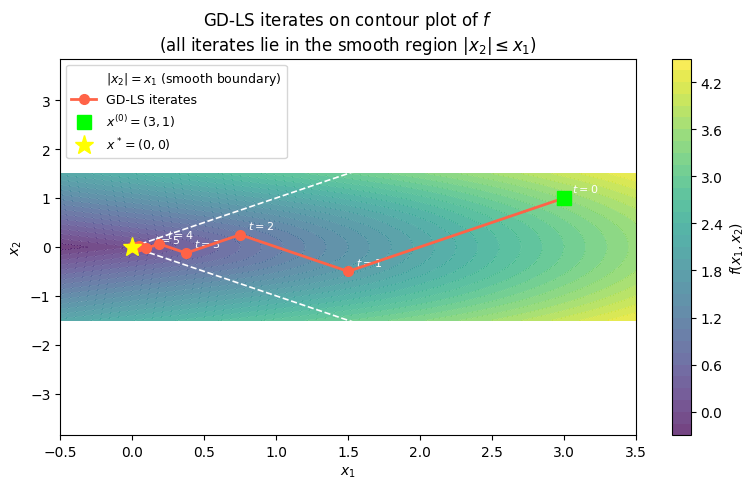

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# GD-LS iterates: x^(t) = (3*(1/2)^t, (-1/2)^t)
T = 12
ts = np.arange(T + 1)
x1_iters = 3 * (0.5 ** ts)
x2_iters = ((-0.5) ** ts)

# Contour plot of f
m = 400
x1g = np.linspace(-0.5, 3.5, m)
x2g = np.linspace(-1.5, 1.5, m)
X1, X2 = np.meshgrid(x1g, x2g)
F = np.where(np.abs(X2) <= X1,
             np.sqrt(X1**2 + 3*X2**2),
             (X1 + 3*np.abs(X2)) / 2)

fig, ax = plt.subplots(figsize=(8, 5))
cp = ax.contourf(X1, X2, F, levels=30, cmap="viridis", alpha=0.75)
fig.colorbar(cp, ax=ax, label="$f(x_1, x_2)$")
ax.contour(X1, X2, F, levels=30, colors="white", linewidths=0.4, alpha=0.4)

# Smooth region boundary |x2| = x1
x1_bnd = np.linspace(0, 3.5, 300)
ax.plot(x1_bnd,  x1_bnd, "w--", lw=1.2, label=r"$|x_2|=x_1$ (smooth boundary)")
ax.plot(x1_bnd, -x1_bnd, "w--", lw=1.2)

# Plot iterates
ax.plot(x1_iters, x2_iters, "o-", color="tomato", lw=2, ms=7, zorder=5, label="GD-LS iterates")
ax.plot(x1_iters[0], x2_iters[0], "s", color="lime", ms=10, zorder=6, label=r"$x^{(0)}=(3,1)$")
ax.plot(0, 0, "*", color="yellow", ms=14, zorder=6, label=r"$x^*=(0,0)$")

# Annotate a few iterates
for t in range(min(6, T+1)):
    ax.annotate(f"$t={t}$", (x1_iters[t], x2_iters[t]),
                textcoords="offset points", xytext=(6, 4), fontsize=8, color="white")

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("GD-LS iterates on contour plot of $f$\n(all iterates lie in the smooth region $|x_2| \\leq x_1$)")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## Problem 4

### Part (a) — Subgradient method with constant step size

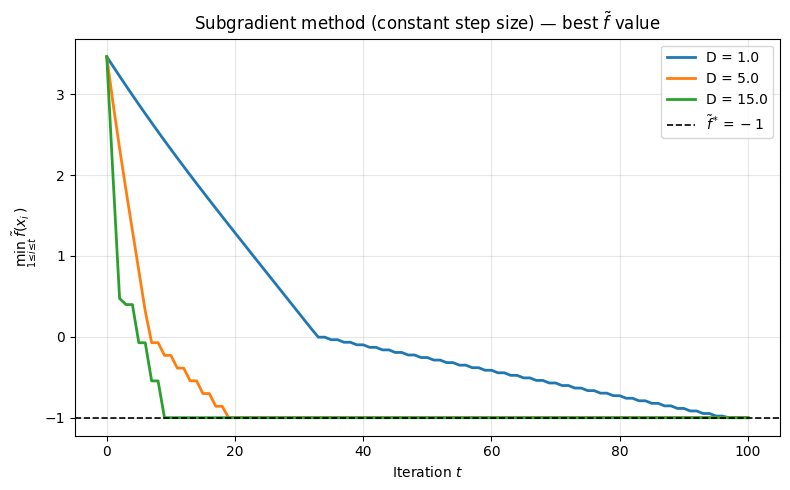

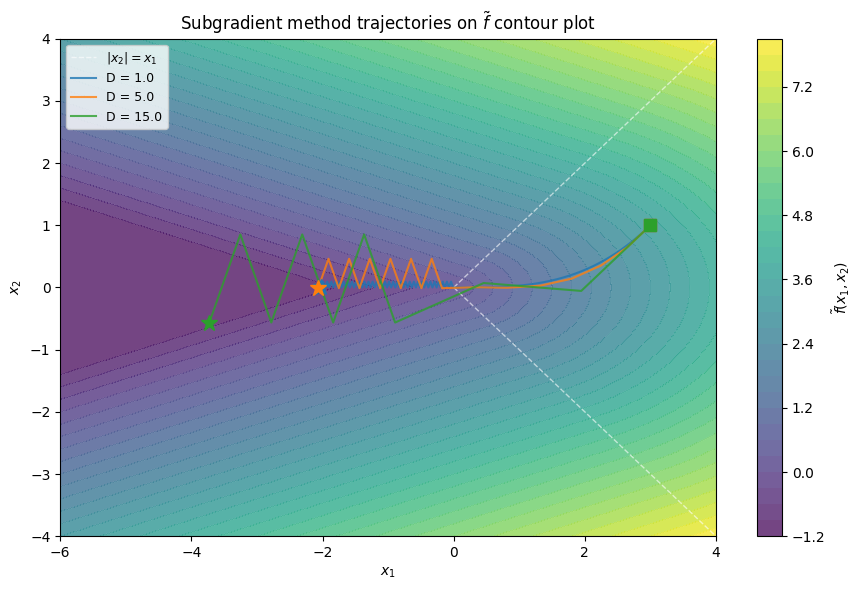

     D      final x1      final x2    best f_tilde
--------------------------------------------------
   1.0       -2.0229       -0.0000         -1.0000
   5.0       -2.0662       -0.0111         -1.0000
  15.0       -3.7252       -0.5634         -1.0000


In [4]:
import numpy as np
import matplotlib.pyplot as plt


def f_tilde(x1, x2):
    """Clipped objective: max(f(x), -1)."""
    if abs(x2) <= x1:
        fx = np.sqrt(x1**2 + 3*x2**2)
    else:
        fx = (x1 + 3*abs(x2)) / 2
    return max(fx, -1.0)


def subgradient(x1, x2):
    """A subgradient of f_tilde at (x1, x2)."""
    fx = (x1 + 3*abs(x2)) / 2 if abs(x2) > x1 else np.sqrt(x1**2 + 3*x2**2)
    if fx <= -1.0:
        return np.array([0.0, 0.0])
    if abs(x2) <= x1:
        r = np.sqrt(x1**2 + 3*x2**2)
        return np.array([x1 / r, 3*x2 / r])
    else:
        return np.array([0.5, 1.5 * np.sign(x2) if x2 != 0 else 0.0])


def subgradient_method_constant(x0, T, D):
    """Returns (best_fs, trajectory) for the constant step size subgradient method."""
    h = D / np.sqrt(T + 1)
    x = np.array(x0, dtype=float)
    best_f = f_tilde(*x)
    best_fs = [best_f]
    traj = [x.copy()]

    for _ in range(T):
        g = subgradient(*x)
        g_norm = np.linalg.norm(g)
        if g_norm > 1e-12:
            x = x - h * g / g_norm
        best_f = min(best_f, f_tilde(*x))
        best_fs.append(best_f)
        traj.append(x.copy())

    return np.array(best_fs), np.array(traj)


x0 = [3.0, 1.0]
T = 100
D_values = [1.0, 5.0, 15.0]
colors = ["tab:blue", "tab:orange", "tab:green"]

results = [(D, *subgradient_method_constant(x0, T, D)) for D in D_values]

# --- Plot 1: best f_tilde over iterations ---
fig, ax = plt.subplots(figsize=(8, 5))
for D, best_fs, _ in results:
    ax.plot(range(T + 1), best_fs, lw=2, label=f"D = {D}")
ax.axhline(-1.0, color="black", ls="--", lw=1.2, label=r"$\tilde{f}^* = -1$")
ax.set_xlabel("Iteration $t$")
ax.set_ylabel(r"$\min_{1 \leq i \leq t}\, \tilde{f}(x_i)$")
ax.set_title("Subgradient method (constant step size) — best $\\tilde{f}$ value")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: trajectories on contour plot ---
m = 400
x1g = np.linspace(-6, 4, m)
x2g = np.linspace(-4, 4, m)
X1, X2 = np.meshgrid(x1g, x2g)
F_raw = np.where(np.abs(X2) <= X1, np.sqrt(X1**2 + 3*X2**2), (X1 + 3*np.abs(X2)) / 2)
F_clip = np.maximum(F_raw, -1.0)

fig, ax = plt.subplots(figsize=(9, 6))
cp = ax.contourf(X1, X2, F_clip, levels=30, cmap="viridis", alpha=0.75)
fig.colorbar(cp, ax=ax, label=r"$\tilde{f}(x_1, x_2)$")
ax.contour(X1, X2, F_clip, levels=30, colors="white", linewidths=0.4, alpha=0.3)

x1_bnd = np.linspace(0, 4, 300)
ax.plot(x1_bnd,  x1_bnd, "w--", lw=1.0, alpha=0.6, label=r"$|x_2|=x_1$")
ax.plot(x1_bnd, -x1_bnd, "w--", lw=1.0, alpha=0.6)

for (D, _, traj), c in zip(results, colors):
    ax.plot(traj[:, 0], traj[:, 1], "-", color=c, lw=1.5, alpha=0.8, label=f"D = {D}")
    ax.plot(traj[0, 0], traj[0, 1], "s", color=c, ms=8, zorder=6)
    ax.plot(traj[-1, 0], traj[-1, 1], "*", color=c, ms=12, zorder=6)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Subgradient method trajectories on $\\tilde{f}$ contour plot")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# --- Summary ---
print(f"{'D':>6}  {'final x1':>12}  {'final x2':>12}  {'best f_tilde':>14}")
print("-" * 50)
for D, best_fs, traj in results:
    print(f"{D:>6.1f}  {traj[-1,0]:>12.4f}  {traj[-1,1]:>12.4f}  {best_fs[-1]:>14.4f}")


### Part (b) — Subgradient method with Polyak's step size

$\tilde{f}^* = -1$, since $\tilde{f}(x) = \max\{f(x), -1\} \ge -1$ for all $x$, and equality is achieved whenever $f(x) \le -1$ (e.g. at $(-2, 0)$: $f(-2,0) = \tfrac{-2+0}{2} = -1$).

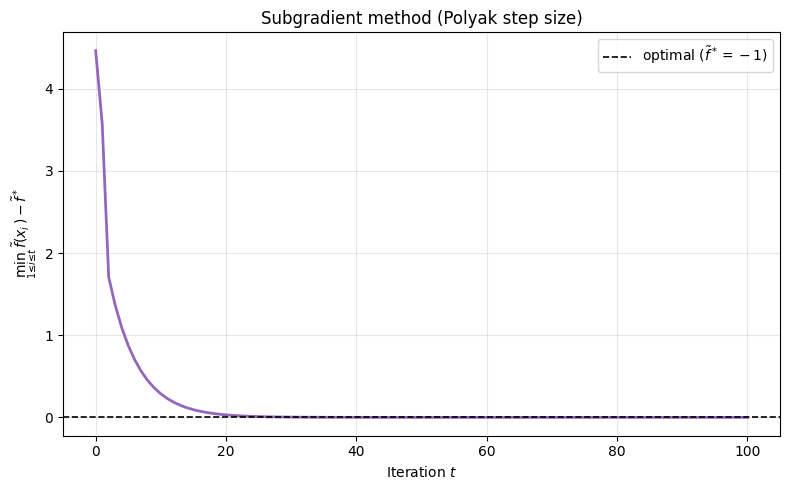

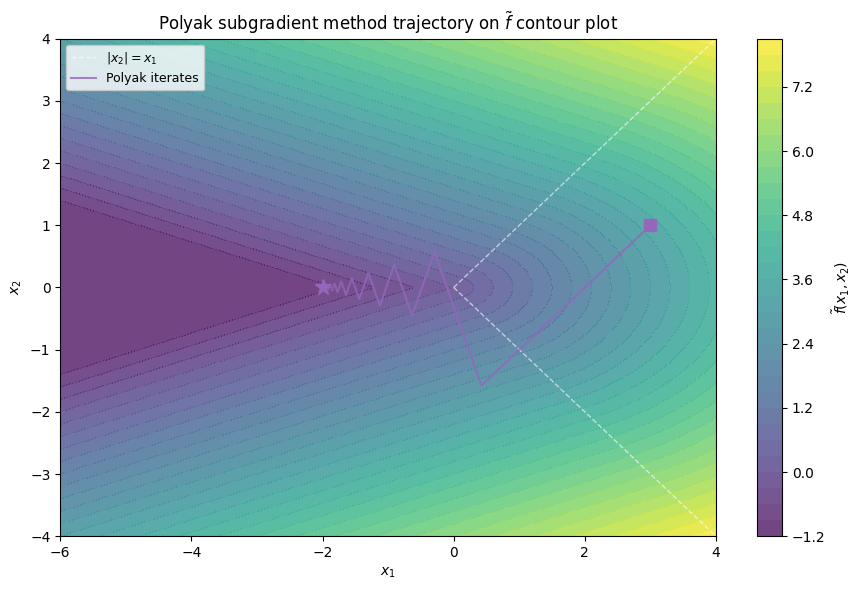

Final iterate: x1 = -2.0000, x2 = 0.0000
Best f_tilde achieved: -1.0000  (f* = -1.0)


In [5]:
def subgradient_method_polyak(x0, T):
    """Subgradient method with Polyak step: x_{t+1} = x_t - h_t * g_t,
    h_t = (f_tilde(x_t) - f*) / ||g_t||^2, f* = -1."""
    f_star = -1.0
    x = np.array(x0, dtype=float)
    best_f = f_tilde(*x)
    best_fs = [best_f]
    traj = [x.copy()]

    for _ in range(T):
        g = subgradient(*x)
        g_norm_sq = np.dot(g, g)
        if g_norm_sq > 1e-24:
            h = (f_tilde(*x) - f_star) / g_norm_sq
        else:
            h = 1.0
        x = x - h * g
        best_f = min(best_f, f_tilde(*x))
        best_fs.append(best_f)
        traj.append(x.copy())

    return np.array(best_fs), np.array(traj)


x0 = [3.0, 1.0]
T = 100
f_star = -1.0

best_fs_p, traj_p = subgradient_method_polyak(x0, T)

# --- Plot 1: min f_tilde - f* over iterations ---
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(T + 1), best_fs_p - f_star, lw=2, color="tab:purple")
ax.axhline(0.0, color="black", ls="--", lw=1.2, label=r"optimal ($\tilde{f}^* = -1$)")
ax.set_xlabel("Iteration $t$")
ax.set_ylabel(r"$\min_{1 \leq i \leq t}\, \tilde{f}(x_i) - \tilde{f}^*$")
ax.set_title("Subgradient method (Polyak step size)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Plot 2: trajectory on contour plot ---
fig, ax = plt.subplots(figsize=(9, 6))
cp = ax.contourf(X1, X2, F_clip, levels=30, cmap="viridis", alpha=0.75)
fig.colorbar(cp, ax=ax, label=r"$\tilde{f}(x_1, x_2)$")
ax.contour(X1, X2, F_clip, levels=30, colors="white", linewidths=0.4, alpha=0.3)

x1_bnd = np.linspace(0, 4, 300)
ax.plot(x1_bnd,  x1_bnd, "w--", lw=1.0, alpha=0.6, label=r"$|x_2|=x_1$")
ax.plot(x1_bnd, -x1_bnd, "w--", lw=1.0, alpha=0.6)

ax.plot(traj_p[:, 0], traj_p[:, 1], "-", color="tab:purple", lw=1.5, alpha=0.8, label="Polyak iterates")
ax.plot(traj_p[0, 0], traj_p[0, 1], "s", color="tab:purple", ms=8, zorder=6)
ax.plot(traj_p[-1, 0], traj_p[-1, 1], "*", color="tab:purple", ms=12, zorder=6)

ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.set_title("Polyak subgradient method trajectory on $\\tilde{f}$ contour plot")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"Final iterate: x1 = {traj_p[-1,0]:.4f}, x2 = {traj_p[-1,1]:.4f}")
print(f"Best f_tilde achieved: {best_fs_p[-1]:.4f}  (f* = {f_star})")
